In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"E:\vs\base_module1\Bike Rental Demand Prediction\dataset\hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.shape

(17379, 17)

In [4]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [5]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
df["cnt"].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [10]:
df.corr(numeric_only=True)["cnt"].sort_values(ascending=False)

cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
instant       0.278379
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64

In [11]:
features = ["temp", "atemp", "hum", "windspeed", "hr"]
target = "cnt"
X = df[features]
y = df[target]

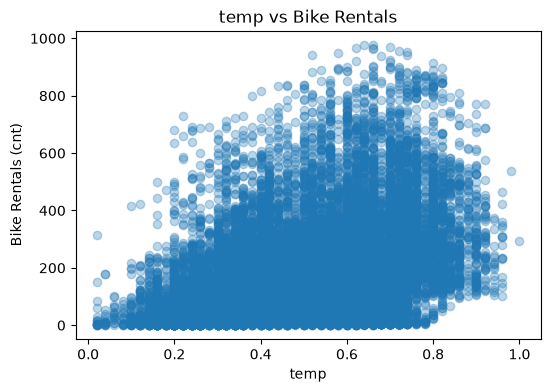

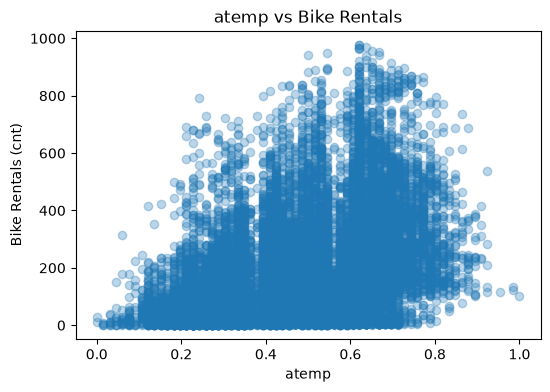

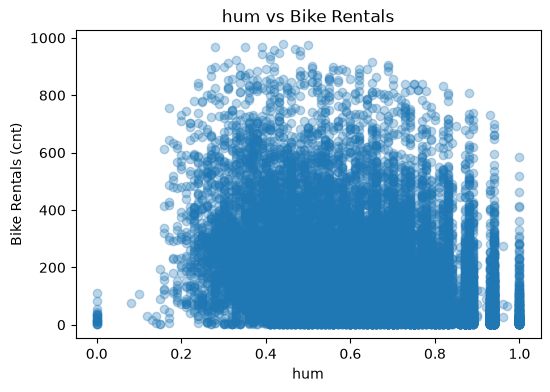

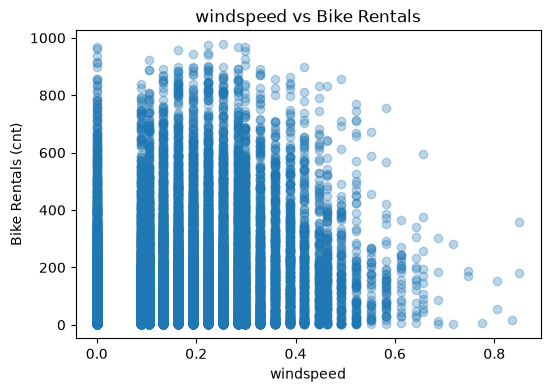

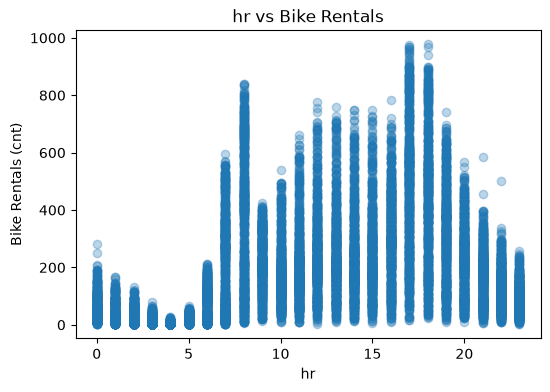

In [12]:
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df["cnt"], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel("Bike Rentals (cnt)")
    plt.title(f"{feature} vs Bike Rentals")
    plt.show()

In [13]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_end = int(0.60 * len(X))
val_end = int(0.80 * len(X))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (10427, 5)
Validation: (3476, 5)
Test: (3476, 5)


In [14]:
train_mean = X_train.mean()
train_std = X_train.std()

X_train_scaled = (X_train - train_mean) / train_std
X_val_scaled = (X_val - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std
X_train_scaled.head()

,temp,atemp,hum,windspeed,hr
12830,1.574633,1.289411,-1.851145,0.037180,1.083278
8688,-1.337148,-1.450607,-1.124167,0.281782,1.228161
7091,-0.921179,-1.009007,0.174008,0.770167,-1.379727
12230,1.470641,1.377497,-0.552970,1.380443,1.083278
431,-1.233156,-1.450607,-0.345262,1.625045,-1.669493


In [15]:
X_train_gd = X_train_scaled.to_numpy()
y_train_gd = y_train.to_numpy()
X_train_gd = np.c_[
    np.ones(X_train_gd.shape[0]),
    X_train_gd
]

In [16]:
import time
weights = np.zeros(X_train_gd.shape[1])
learning_rate = 0.01
epochs = 1000

cost_history = []

start_time = time.time()

for i in range(epochs):
    predictions = X_train_gd @ weights

    error = predictions - y_train_gd

    cost = np.mean(error ** 2)

    gradient = (2 / len(y_train_gd)) * (X_train_gd.T @ error)

    weights = weights - learning_rate * gradient

    cost_history.append(cost)

gd_weights = weights

gd_time = time.time() - start_time

In [17]:
X_train_ne = X_train_gd.copy()
y_train_ne = y_train_gd.copy()
start_time = time.time()
normal_weights = np.linalg.pinv(
    X_train_ne.T @ X_train_ne
) @ X_train_ne.T @ y_train_ne
normal_time = time.time() - start_time

print("GD weights:", len(gd_weights))
print("Normal weights:", len(normal_weights))

GD weights: 6
Normal weights: 6


In [18]:
print(f"Gradient Descent Time: {gd_time:.6f} seconds")
print(f"Normal Equation Time: {normal_time:.6f} seconds")

Gradient Descent Time: 0.140332 seconds
Normal Equation Time: 0.251407 seconds


In [19]:
features = X.columns.tolist()
comparison = pd.DataFrame({
    "Feature": ["Intercept"] + features,
    "Gradient Descent": gd_weights,
    "Normal Equation": normal_weights
})
comparison

,Feature,Gradient Descent,Normal Equation
0,Intercept,187.263546,187.263547
1,temp,30.588173,28.597473
2,atemp,31.557698,33.551090
3,hum,-37.989977,-38.010483
4,windspeed,1.545056,1.623342
5,hr,52.704962,52.694985


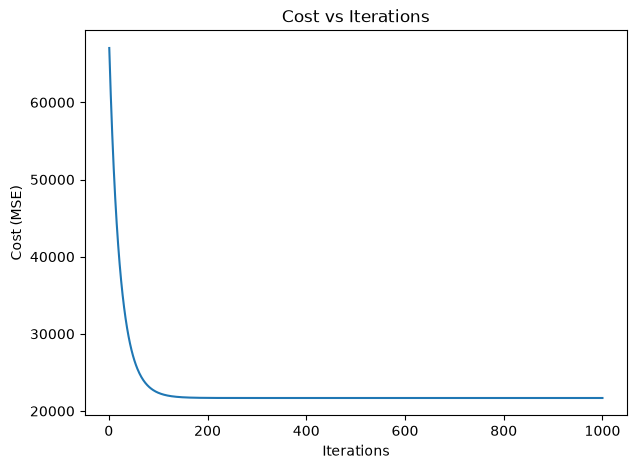

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(
    range(1, epochs + 1),
    cost_history
)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations")

plt.show()

In [21]:
def polynomial_features(X, degree):

    X_poly = X.copy()
    
    for d in range(2, degree + 1):
        X_poly = np.c_[X_poly, X ** d]
    
    return X_poly

In [22]:
degrees = [1, 2, 3, 5]

train_errors = []
val_errors = []
for degree in degrees:

    X_train_poly = polynomial_features(X_train_scaled.to_numpy(), degree)
    X_val_poly = polynomial_features(X_val_scaled.to_numpy(), degree)

    X_train_poly = np.c_[
        np.ones(X_train_poly.shape[0]),
        X_train_poly
    ]

    X_val_poly = np.c_[
        np.ones(X_val_poly.shape[0]),
        X_val_poly
    ]

    weights = np.linalg.pinv(
        X_train_poly.T @ X_train_poly
    ) @ X_train_poly.T @ y_train.to_numpy()

    train_predictions = X_train_poly @ weights
    val_predictions = X_val_poly @ weights

    train_mse = np.mean(
        (train_predictions - y_train.to_numpy()) ** 2
    )

    val_mse = np.mean(
        (val_predictions - y_val.to_numpy()) ** 2
    )

    train_errors.append(train_mse)
    val_errors.append(val_mse)

In [23]:
results = pd.DataFrame({
    "Degree": degrees,
    "Train Error": train_errors,
    "Validation Error": val_errors
})

results

,Degree,Train Error,Validation Error
0,1,21687.208779,22901.138568
1,2,18391.003722,19287.472083
2,3,16911.224673,18151.278998
3,5,16354.248443,17473.617001


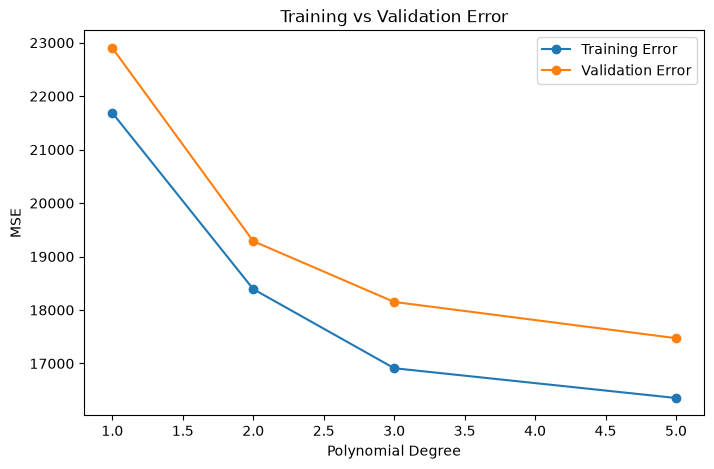

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    val_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Validation Error")
plt.legend()

plt.show()

In [25]:
for degree, train_error, val_error in zip(
    degrees, train_errors, val_errors
):
    print(
        f"Degree {degree}: "
        f"Train Error = {train_error:.2f}, "
        f"Validation Error = {val_error:.2f}"
    )

Degree 1: Train Error = 21687.21, Validation Error = 22901.14
Degree 2: Train Error = 18391.00, Validation Error = 19287.47
Degree 3: Train Error = 16911.22, Validation Error = 18151.28
Degree 5: Train Error = 16354.25, Validation Error = 17473.62


In [26]:
training_sizes = [50, 100, 200, 300, 400]

train_errors_lc = []
val_errors_lc = []

In [27]:
for size in training_sizes:

    X_small = X_train_scaled.iloc[:size].to_numpy()
    y_small = y_train.iloc[:size].to_numpy()

    X_small = np.c_[
        np.ones(X_small.shape[0]),
        X_small
    ]

    X_val_lc = X_val_scaled.to_numpy()

    X_val_lc = np.c_[
        np.ones(X_val_lc.shape[0]),
        X_val_lc
    ]

    weights = np.linalg.pinv(
        X_small.T @ X_small
    ) @ X_small.T @ y_small

    train_predictions = X_small @ weights
    val_predictions = X_val_lc @ weights

    train_mse = np.mean(
        (train_predictions - y_small) ** 2
    )

    val_mse = np.mean(
        (val_predictions - y_val.to_numpy()) ** 2
    )

    train_errors_lc.append(train_mse)
    val_errors_lc.append(val_mse)

In [28]:
learning_curve_results = pd.DataFrame({
    "Training Size": training_sizes,
    "Training Error": train_errors_lc,
    "Validation Error": val_errors_lc
})

learning_curve_results

,Training Size,Training Error,Validation Error
0,50,27317.309311,26768.234418
1,100,22701.177681,25007.278238
2,200,21048.642114,23414.242474
3,300,19506.853296,23257.924423
4,400,20720.816129,23200.876988


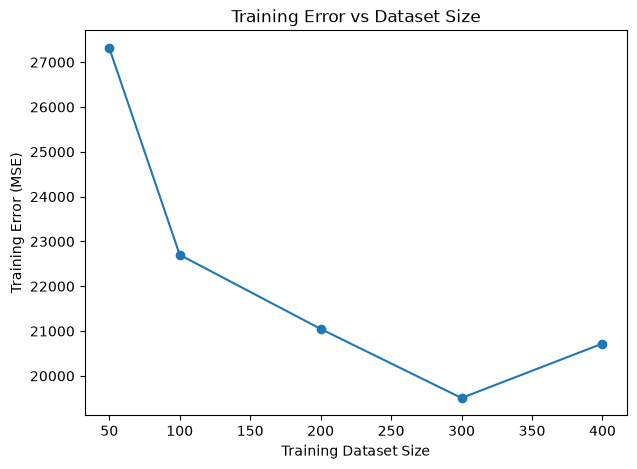

In [29]:
plt.figure(figsize=(7, 5))

plt.plot(
    training_sizes,
    train_errors_lc,
    marker="o"
)

plt.xlabel("Training Dataset Size")
plt.ylabel("Training Error (MSE)")
plt.title("Training Error vs Dataset Size")

plt.show()

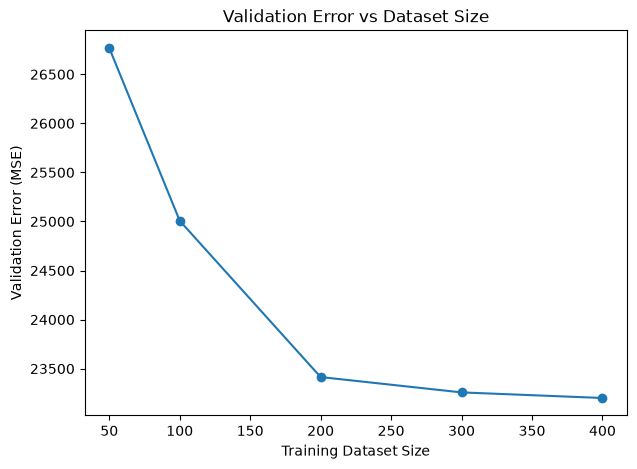

In [30]:
plt.figure(figsize=(7, 5))

plt.plot(
    training_sizes,
    val_errors_lc,
    marker="o"
)

plt.xlabel("Training Dataset Size")
plt.ylabel("Validation Error (MSE)")
plt.title("Validation Error vs Dataset Size")

plt.show()

In [31]:
# Save trained model and preprocessing values

np.savez(
    "bike_rental_model.npz",
    weights=gd_weights,
    mean=train_mean.to_numpy(),
    std=train_std.to_numpy()
)

print("Model saved successfully!")

Model saved successfully!
